# Coda-click-mismatches

In this notebook we enumerate which click is the mismatched click in each coda that has a single mismatch.

In [1]:
import re
import pandas as pd
import numpy as np

## Load coda results

The `codasp.csv` file contains coda metadata and results of coda and click vowel assignments as determined by spectral analysis. See [`README.md`](README.md) for the details of all columns in this file.

In [2]:
spcols = {
    'codanum': str,         # Coda identifier
    'whale': str,           # Name of whale that produced the coda
    'autovpkcodastr': str,  # Sequence of 'a' and 'i' values for each click in the coda, as assigned by processing
    'autovbycoda': str,     # 'a' or 'i' if all clicks in the coda match, otherwise '?'
    'codatype': str,        # Traditional coda type
    'handv': str,           # Coda vowel label as determined by a human anotator
    'mismatchpct': float    # Percentage of clicks in a coda that do not match the most frequent value in the coda ([0.0, 0.5])
}
spdf = pd.read_csv('codasp.csv', usecols=spcols.keys(), dtype=spcols)
spdf

,codanum,autovpkcodastr,autovbycoda,mismatchpct,whale,codatype,handv
0,4933,iiiii,i,0.0,ATWOOD,1+1+3,i
1,4934,iiiii,i,0.0,ATWOOD,1+1+3,i
2,4935,iiiii,i,0.0,ATWOOD,1+1+3,i
3,4936,iiiii,i,0.0,ATWOOD,1+1+3,i
4,4937,iiiii,i,0.0,ATWOOD,1+1+3,i
...,...,...,...,...,...,...,...
1370,8856,iaaaa,?,0.2,LAIUS,1+1+3,a
1371,8857,iaaai,?,0.4,LAIUS,1+1+3,a
1372,8858,iiaaa,?,0.4,LAIUS,1+1+3,a
1373,8859,iaaaa,?,0.2,LAIUS,1+1+3,a


### Exclude codas with no or equal mismatches

Codas that have a vowel label assigned by spectral analysis do not have mismatches and are therefore excluded (`autovbycoda not in ["a", "i"]`). For codas that have an equal number of 'a' and 'i' click labels (`mismatchpct == 0.5`) it is not possible to identify which clicks are the mismatches and which are the modal value, so these are excluded as well.

In [3]:
oddf = spdf.query(f'autovbycoda not in ["a", "i"] and mismatchpct != 0.5').copy()
oddf

,codanum,autovpkcodastr,autovbycoda,mismatchpct,whale,codatype,handv
43,5022,iiiia,?,0.200000,ATWOOD,1+1+3,i
44,5023,iiiaa,?,0.400000,ATWOOD,1+1+3,i
46,5025,iiiiia,?,0.166667,ATWOOD,6-NOISE,i
51,5030,iiiaa,?,0.400000,ATWOOD,1+1+3,i
58,5041,iaaaa,?,0.200000,ATWOOD,1+1+3,NaN
...,...,...,...,...,...,...,...
1368,8854,aaaai,?,0.200000,LAIUS,1+1+3,a
1370,8856,iaaaa,?,0.200000,LAIUS,1+1+3,a
1371,8857,iaaai,?,0.400000,LAIUS,1+1+3,a
1372,8858,iiaaa,?,0.400000,LAIUS,1+1+3,a


### Find indexes and counts of mismatched clicks

Split the `autovpkcodastr` into its constituent click vowel assignments. Find the indexes and counts of the 'a' and 'i' clicks, then determine which are the mismatched clicks. Add these values to `oddf`.

The resulting columns are:

 * `clchars`: array of click vowel assignments in the coda
 * `iidx`: array of 'i' click indexes (0 == first click, 1 == second click, ...) in the coda
 * `icnt`: count of 'i' clicks in the coda
 * `aidx`: array of 'a' click indexes in the coda
 * `acnt`: count of 'a' clicks in the coda
 * `mmidx`: indexes of the mismatched clicks in the coda, i.e. the `iidx` of `aidx` values, whichever is less commonly found in the coda
 * `mmcnt`: count of mismatched clicks in the coda

In [4]:
oddf['clchars'] = [np.array(list(s)) for s in oddf['autovpkcodastr']]
oddf['iidx'] = [np.nonzero(a == 'i')[0] for a in oddf['clchars']]
oddf['icnt'] = [len(a) for a in oddf['iidx']]
oddf['aidx'] = [np.nonzero(a == 'a')[0] for a in oddf['clchars']]
oddf['acnt'] = [len(a) for a in oddf['aidx']]
oddf['mmidx'] = np.where(oddf['icnt'] > oddf['acnt'], oddf['aidx'], oddf['iidx'])
oddf['mmcnt'] = [len(a) for a in oddf['mmidx']]
oddf['mmcnt'] = pd.Categorical(
    oddf['mmcnt'],
    categories=np.arange(1, oddf['mmcnt'].max()+1),
    ordered=True
)
oddf

,codanum,autovpkcodastr,autovbycoda,mismatchpct,whale,codatype,handv,clchars,iidx,icnt,aidx,acnt,mmidx,mmcnt
43,5022,iiiia,?,0.200000,ATWOOD,1+1+3,i,"[i, i, i, i, a]","[0, 1, 2, 3]",4,[4],1,[4],1
44,5023,iiiaa,?,0.400000,ATWOOD,1+1+3,i,"[i, i, i, a, a]","[0, 1, 2]",3,"[3, 4]",2,"[3, 4]",2
46,5025,iiiiia,?,0.166667,ATWOOD,6-NOISE,i,"[i, i, i, i, i, a]","[0, 1, 2, 3, 4]",5,[5],1,[5],1
51,5030,iiiaa,?,0.400000,ATWOOD,1+1+3,i,"[i, i, i, a, a]","[0, 1, 2]",3,"[3, 4]",2,"[3, 4]",2
58,5041,iaaaa,?,0.200000,ATWOOD,1+1+3,NaN,"[i, a, a, a, a]",[0],1,"[1, 2, 3, 4]",4,[0],1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1368,8854,aaaai,?,0.200000,LAIUS,1+1+3,a,"[a, a, a, a, i]",[4],1,"[0, 1, 2, 3]",4,[4],1
1370,8856,iaaaa,?,0.200000,LAIUS,1+1+3,a,"[i, a, a, a, a]",[0],1,"[1, 2, 3, 4]",4,[0],1
1371,8857,iaaai,?,0.400000,LAIUS,1+1+3,a,"[i, a, a, a, i]","[0, 4]",2,"[1, 2, 3]",3,"[0, 4]",2
1372,8858,iiaaa,?,0.400000,LAIUS,1+1+3,a,"[i, i, a, a, a]","[0, 1]",2,"[2, 3, 4]",3,"[0, 1]",2


## Summarize

### Report mismatches for codas with exactly one mismatch

First find codas with exactly one mismatche and assign to `mm1df`.

In [5]:
mm1df = oddf.query('mmcnt == 1').copy()
mm1df

,codanum,autovpkcodastr,autovbycoda,mismatchpct,whale,codatype,handv,clchars,iidx,icnt,aidx,acnt,mmidx,mmcnt
43,5022,iiiia,?,0.200000,ATWOOD,1+1+3,i,"[i, i, i, i, a]","[0, 1, 2, 3]",4,[4],1,[4],1
46,5025,iiiiia,?,0.166667,ATWOOD,6-NOISE,i,"[i, i, i, i, i, a]","[0, 1, 2, 3, 4]",5,[5],1,[5],1
58,5041,iaaaa,?,0.200000,ATWOOD,1+1+3,NaN,"[i, a, a, a, a]",[0],1,"[1, 2, 3, 4]",4,[0],1
74,5089,aiiii,?,0.200000,ATWOOD,1+1+3,i,"[a, i, i, i, i]","[1, 2, 3, 4]",4,[0],1,[0],1
79,5094,iaaaa,?,0.200000,ATWOOD,1+1+3,a,"[i, a, a, a, a]",[0],1,"[1, 2, 3, 4]",4,[0],1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1348,8649,iaaaa,?,0.200000,JOCASTA,5R1,a,"[i, a, a, a, a]",[0],1,"[1, 2, 3, 4]",4,[0],1
1350,8651,iaaaa,?,0.200000,JOCASTA,5R1,a,"[i, a, a, a, a]",[0],1,"[1, 2, 3, 4]",4,[0],1
1368,8854,aaaai,?,0.200000,LAIUS,1+1+3,a,"[a, a, a, a, i]",[4],1,"[0, 1, 2, 3]",4,[4],1
1370,8856,iaaaa,?,0.200000,LAIUS,1+1+3,a,"[i, a, a, a, a]",[0],1,"[1, 2, 3, 4]",4,[0],1


Concatenate all mismatch indexes into the categorical array `allmm1idx`. The indexes show the positions in the coda where mismatches occur (0 == first click, 1 == second click, ...).

In [6]:
allmm1idx = np.hstack(mm1df['mmidx'])
allmm1idx = pd.Categorical(allmm1idx, categories=range(allmm1idx.max()+1), ordered=True)
allmm1idx

[4, 5, 0, 0, 0, ..., 0, 0, 4, 0, 0]
Length: 165
Categories (8, int64): [0 < 1 < 2 < 3 < 4 < 5 < 6 < 7]

Report on the position counts.


N of codas with exactly one mismatch: 165
N of mismatched clicks in codas with exactly one mismatch: 165
N of mismatches at click indexes:
    0: 79
    1: 28
    2: 17
    3: 10
    4: 25
    5: 3
    6: 2
    7: 1



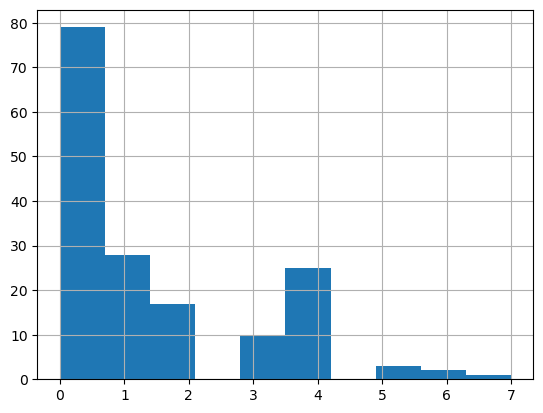

In [7]:
mismatchstr = '\n'.join([
    f'    {k}: {v}' for k, v in allmm1idx.value_counts().items()
])
print(f'''
N of codas with exactly one mismatch: {len(mm1df)}
N of mismatched clicks in codas with exactly one mismatch: {len(allmm1idx)}
N of mismatches at click indexes:
{mismatchstr}
''')
pd.Series(allmm1idx).hist();